In [1]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
import astropy 
import astropy.units as u
from astropy.constants import M_sun
from astropy.constants import c
from astropy.constants import L_sun
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import L_sun
L_sun_eps = L_sun.cgs.value
#plotsdir = "/mnt/home/kprofit/plots/"
plotsdir = "/beegfs/general/kprofit/analysis_scripts"

In [2]:
#File Path cell
import sys
sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages
#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
import read_snap_files as rsf
#snap_dir_orig = "/mnt/home/skoudmani/ceph/ADIOSProj/CIRCUMBINARY/NEW_SIM/q01e00i00/bhspin_snapshot"
snap_dir_orig = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/"
snap_name = rsf.get_snap_filename(snap_dir_orig, 0, snap_prefix="snapshot")
unitlength_in_cm = rsf.get_attribute(snap_name, "UnitLength_in_cm", param=True) #How much one 'code length unit' is in cm
unitmass_in_g = rsf.get_attribute(snap_name, "UnitMass_in_g", param=True)  #How much one 'code mass unit' is in grams
unitvelocity_in_cm_per_s = rsf.get_attribute(snap_name, "UnitVelocity_in_cm_per_s", param=True)  #How much one 'code velocity unit' is in cm per second
unittime_in_s = unitlength_in_cm / unitvelocity_in_cm_per_s   #How much one 'code time unit' is in seconds


In [11]:
print(snap_name)
import os
print(os.path.exists(snap_name))

/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin//snapshot_100.hdf5
True


In [3]:
#Constants Cell
gamma = 1.4
c1 = [5.712,4.073] #c1 in soft and hard X-ray respectively
c2= [17.67,12.60] #c2 in soft and hard X-ray respectively
k1= [-0.026,0.278] #k1 in soft and hard X-ray respectively
k2= [0.278,0.278] #k2 in soft and hard X-ray respectively

c1_avg = [np.mean(c1)] #Mean c1 value between hard and soft x-ray
c2_avg = [np.mean(c2)] #Mean c2 value between hard and soft x-ray
k1_avg = [np.mean(k1)] #Mean k1 value between hard and soft x-ray
k2_avg = [np.mean(k2)] #Mean k2 value between hard and soft x-ray

F_telescope_athena = [1.6*10**-17, 11*10**-17,100] #Athena DEEP and WIDE flux sensitivity respectively
F_telescope_lynx = [2.0*10**-19,2.0*10**-18,100] #Lynx DEEP and WIDE flux sensitiviy respectively
F_telescope_axis = [1.4*10**-18,2.8*10**-16,100] #AXIS DEEP and WIDE flux sensitivity respectively
#print(F_telescope_athena)
#print(F_telescope_lynx)
#print(F_telescope_axis)

In [4]:
#Functions Cell

def z1(a):
    return 1 + (1 - a**2)**(1/3)*(1+a)**(1/3)+(1-a)**(1/3) #Function of spin a
def z2(a):
    return np.sqrt(3*a**2 + z1(a)**2) #Function of spin a
def Lam(a):
    Lam1 = 3 + z2(a) - np.sqrt((3-z1(a))*(3+z1(a)+2*z2(a))) #Lambda in prograde
    Lam2 = 3 + z2(a) + np.sqrt((3-z1(a))*(3+z1(a)+2*z2(a))) #Lambda in retrograde
    return Lam1,Lam2
def eta(a,corotating=True): 
    Lam1,Lam2 = Lam(a)
    eta1 = 1 - np.sqrt(1-(2/(3*Lam1)))
    eta2 = 1 - np.sqrt(1-(2/(3*Lam2))) #Radiative effeciency 
    if corotating:
        return eta1 
    else:
        return eta2

#Calculate Luminosity
def calculate_luminosities(a,mdot_cgs): 
    c_light_cgs = c.cgs.value 
    rad_eff = eta(a)
    print(np.shape(rad_eff))
    print(np.shape(mdot_cgs))
    L = rad_eff * mdot_cgs * c_light_cgs**2
    return L

#Calculate luminosity distance
z = np.linspace(0.0,15,100)

def calculate_lum_dist(z):
    lum_dist = cosmo.luminosity_distance(z) * (3.086*10**24) 
    #here lum_dist is a local variable, it will only be available to the 'outside' code by calling the function
    return lum_dist
lum_dist = calculate_lum_dist(z) #call the function and save the result to the global variable lum_dist

#Calculate Detectable Luminosity
def calculate_L_detectable(lum_dist, F_telescope):
    L_detectable = (F_telescope) * (4 * np.pi * lum_dist**2)
    return L_detectable

#Calculate X-ray Luminosity
def get_bol_correction(bol_lum,c1,c2,k1,k2):
    Lum_band = (bol_lum) / ((c1*(bol_lum/((10**10)*L_sun_eps))**k1)) + ((c2*(bol_lum/((10**10)*L_sun_eps))**k2))
    return Lum_band

#Calculate avg X-ray Luminosity
def get_bol_correction_avg(bol_lum,c1_avg,c2_avg,k1_avg,k2_avg):
    Lum_band_avg = (bol_lum) / ((c1_avg*(bol_lum/((10**10)*L_sun_eps))**k1_avg)) + ((c2_avg*(bol_lum/((10**10)*L_sun_eps))**k2_avg))
    return Lum_band_avg


(100,)
(3,)


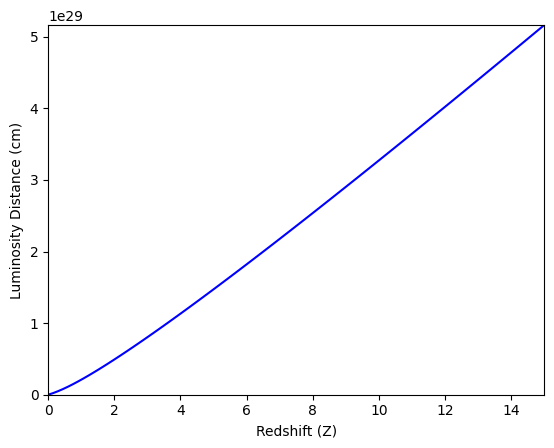

In [5]:
#Plot Luminsoity distance as a function of redshift

plt.plot(z,lum_dist,'b')
plt.ylabel("Luminosity Distance (cm)")
plt.xlabel("Redshift (Z)")
plt.margins(x=0)
plt.margins(y=0)

#plt.axhline(y=4e29, color='r', linestyle='-')


print(np.shape(lum_dist))
print(np.shape(F_telescope_axis))

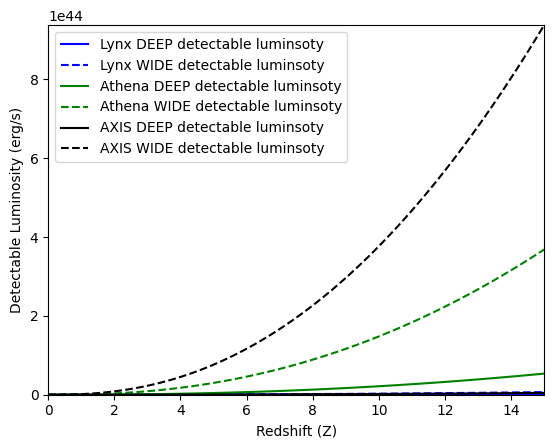

In [6]:
#Detectable Luminosity as Function of redshift

lynx_1 = calculate_L_detectable(lum_dist,F_telescope_lynx[0])
lynx_2 = calculate_L_detectable(lum_dist,F_telescope_lynx[1])

athena_1 = calculate_L_detectable(lum_dist,F_telescope_athena[0])
athena_2 = calculate_L_detectable(lum_dist,F_telescope_athena[1])

axis_1 = calculate_L_detectable(lum_dist,F_telescope_axis[0])
axis_2 = calculate_L_detectable(lum_dist,F_telescope_axis[1])

#Plot L_detectable vs. redshift
plt.plot(z,lynx_1, 'b', label='Lynx DEEP detectable luminsoty')
plt.plot(z,lynx_2, 'b--', label='Lynx WIDE detectable luminsoty')
plt.plot(z,athena_1, 'g', label='Athena DEEP detectable luminsoty')
plt.plot(z,athena_2, 'g--', label='Athena WIDE detectable luminsoty')
plt.plot(z,axis_1, 'k', label='AXIS DEEP detectable luminsoty')
plt.plot(z,axis_2, 'k--', label='AXIS WIDE detectable luminsoty')
plt.ylabel("Detectable Luminosity (erg/s)")
plt.xlabel("Redshift (Z)")
#plt.yscale("log")
plt.margins(x=0)
plt.margins(y=0)
plt.style.context('bmh')
plt.legend(loc=0)
#plt.fill_between(z,athena_2)
#plt.fill_between(z,athena_1)

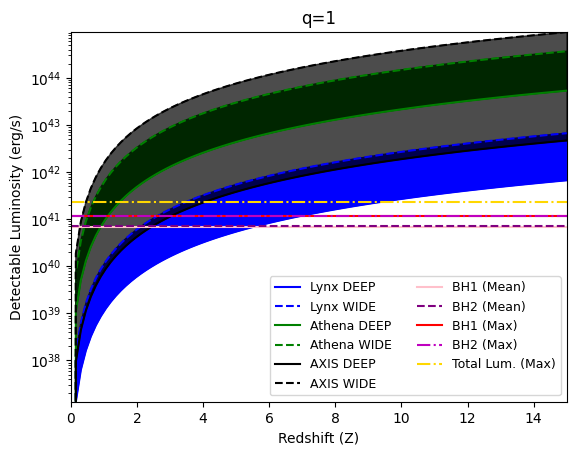

In [10]:
#Plot L_detectable vs. redshift log scale
plt.plot(z,lynx_1, 'b', label='Lynx DEEP')
plt.plot(z,lynx_2, 'b--', label='Lynx WIDE')
plt.plot(z,athena_1, 'g', label='Athena DEEP')
plt.plot(z,athena_2, 'g--', label='Athena WIDE')
plt.plot(z,axis_1, 'k', label='AXIS DEEP')
plt.plot(z,axis_2, 'k--', label='AXIS WIDE')
plt.ylabel("Detectable Luminosity (erg/s)")
plt.xlabel("Redshift (Z)")
plt.title("q=1")
plt.yscale("log")
plt.margins(x=0)
plt.margins(y=0)
plt.style.context('dark')
#plt.legend(loc=0)
plt.fill_between(z,lynx_2,lynx_1.value, color='blue')
plt.fill_between(z,athena_1,athena_2.value, color='green')
plt.fill_between(z,axis_1,axis_2.value, color='black', alpha=0.7)
plt.axhline(y=np.mean(xray_1), color='pink', linestyle='-', label='BH1 (Mean)')
plt.axhline(y=np.mean(xray_2), color='purple', linestyle='--', label='BH2 (Mean)')
plt.axhline(y=np.max(xray_1), color='r', linestyle='-', label='BH1 (Max)')
plt.axhline(y=np.max(xray_2), color='m', linestyle='-.', label='BH2 (Max)')
plt.axhline(y=np.max(xray_3), color='gold', linestyle='-.', label='Total Lum. (Max)')
plt.legend(loc=4, fontsize=13, prop={'size': 9}, ncol=2)

plt.savefig("%s/Xray_Detectable_Lum1.png" %plotsdir,bbox_inches='tight')

In [16]:
##Load in txt files for details on BH and BH spin
run_dir = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/blackhole_details/"
run_dir2 = "/beegfs/general/skoudmani/binary_proj/adios_runs/production_binary/misal_td/output_bhspin/blackhole_details/"
#run_dir = "/mnt/home/skoudmani/ceph/ADIOSProj/CIRCUMBINARY/NEW_SIM/q01e00i00/analysis/"

details_file = "bh1_details.dat"
spin_file = "bh1_bhspin.dat"
details_file2 = "bh2_details.dat"
spin_file2 = "bh2_bhspin.dat"

colors = ["blue", "green", "black"]
titles = ["q=1", "q=3"]

0
(9001,)
(9001,)
(9001,)
(9001,)
1.1816307391213171e+41
2.3632557259067198e+41
1
(9001,)
(9001,)
(9001,)
(9001,)
1.1816307391213171e+41
2.3632557259067198e+41


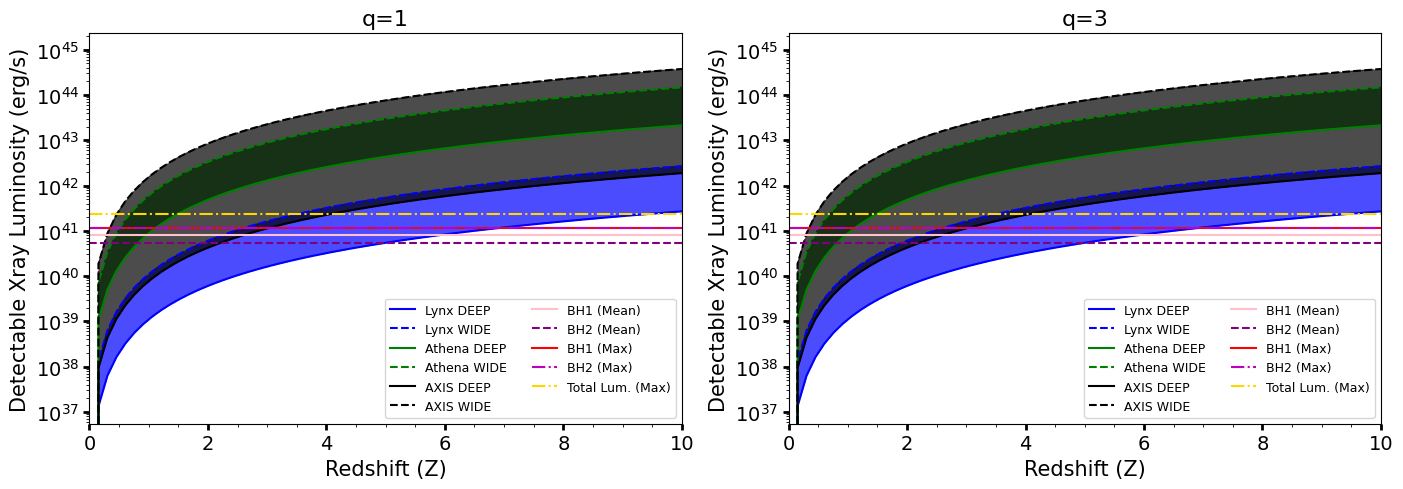

In [18]:
#Create subplots of detectable x-ray luminosity and for each iteration of mean and max luminosity

plt.figure(figsize=(21, 5))
plt.subplots_adjust()
#plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
#plt.suptitle("X-ray Telescope Detectable Luminosity", fontsize=18, y=0.95)

#loop through the length of tickers and keep track of index
for i, run_dir in enumerate([run_dir, run_dir2]):
    print(i)
    #Load in data
    spin_data = np.loadtxt(run_dir+spin_file)
    bh_data = np.loadtxt(run_dir+details_file)
    bh_data2 = np.loadtxt(run_dir2+details_file2)
    spin_data2 = np.loadtxt(run_dir2+spin_file2)
    time = spin_data[:,0][:9001] * 0.978462
    spin = spin_data[:,3][:9001]
    time2 = spin_data2[:,0][:9001]
    spin2 = spin_data2[:,3][:9001]
    efficiency = eta(spin, corotating=True)
    efficiency2 = eta(spin2, corotating=True)
    
    mdot = bh_data[:,2][:9001]
    mdot2 = bh_data2[:,2][:9001]
    mdot_Msunyr = mdot * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
    mdot_cgs = mdot * (unitmass_in_g) / (unittime_in_s)
    mdot_cgs2 = mdot2 * (unitmass_in_g) / (unittime_in_s)#to convert to cgs units
    mdot_Msunyr2 = mdot2 * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
    
    #calculate x-ray luminsoities
    luminosities = calculate_luminosities(spin ,mdot_cgs)
    luminosities2 = calculate_luminosities(spin2 ,mdot_cgs2)

    #xray_h1 = get_bol_correction(luminosities,c1[1],c2[1],k1[1],k2[1])
    #xray_s1 = get_bol_correction(luminosities,c1[0],c2[0],k1[0],k2[0])
    #xray_h2 = get_bol_correction(luminosities2,c1[1],c2[1],k1[1],k2[1])
    #xray_s2 = get_bol_correction(luminosities2,c1[0],c2[0],k1[0],k2[0])
    
    xray_1 = get_bol_correction_avg(luminosities,c1_avg,c2_avg,k1_avg,k2_avg)
    xray_2 = get_bol_correction_avg(luminosities2,c1_avg,c2_avg,k1_avg,k2_avg)
    xray_3 = xray_1 + xray_2
    
    # add a new subplot iteratively
    ax = plt.subplot(1, 3, i + 1)
    ax.plot(z,lynx_1, 'b', label='Lynx DEEP')
    ax.plot(z,lynx_2, 'b--', label='Lynx WIDE')
    ax.plot(z,athena_1, 'g', label='Athena DEEP')
    ax.plot(z,athena_2,'g--', label='Athena WIDE')
    ax.plot(z,axis_1, 'k', label='AXIS DEEP')
    ax.plot(z,axis_2, 'k--', label='AXIS WIDE')
    #ax.legend(loc=1)
    ax.set_title(titles[i],fontsize=16)
    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

    #Plot horizontal line for mean luminosity of each binary
    #print(np.mean(xray_1))
    #print(np.mean(xray_2))
    print(np.max(xray_1))
    print(np.max(xray_3))
    #print(np.max(xray_2))
    #print(np.mean(xray_h2))
    #print(np.mean(xray_s2))
    
    ax.axhline(y=np.mean(xray_1), color='pink', linestyle='-', label='BH1 (Mean)')
    ax.axhline(y=np.mean(xray_2), color='purple', linestyle='--', label='BH2 (Mean)')
    ax.axhline(y=np.max(xray_1), color='r', linestyle='-', label='BH1 (Max)')
    ax.axhline(y=np.max(xray_2), color='m', linestyle='-.', label='BH2 (Max)')
    ax.axhline(y=np.max(xray_3), color='gold', linestyle='-.', label='Total Lum. (Max)')
    ax.legend(loc=4, fontsize=13, prop={'size': 9}, ncol=2)
    
    #chart formatting
    ax.fill_between(z,lynx_2,lynx_1.value, color='blue',alpha=0.7, ls="--")
    ax.fill_between(z,athena_1,athena_2.value, color='green',alpha=0.7, ls=":")
    ax.fill_between(z,axis_1,axis_2.value, color='black', alpha=0.7, ls="-.")
    ax.tick_params(direction='out',which = 'major', length=4, width=2, labelsize=14)
    #ax.tick_params(direction='out',which = 'minor', length=3, width=1)
    ax.set_yscale("log")
    ax.margins(x=0)
    plt.style.context('bmh')
    ax.set_xlabel("Redshift (Z)",fontsize=15)
    ax.set_ylabel("Detectable Xray Luminosity (erg/s)",fontsize=15)
    ax.set_xlim(0,10)
    #ax.axvline(2.5)
    
    ax.minorticks_on()
    plt.tight_layout()
    plt.savefig("%s/Xray_Detectable_Lum.png" %plotsdir,bbox_inches='tight')